#### Tissera Ana Paula - `Notebook TP2`

##### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

## 1. **Diagnóstico de Cáncer de Mama**

### `1.1)` Análisis exploratorio de los datos

##### Cargar data

In [2]:
dev_path = "data/Problem_1/raw//cell_diagnosis_dev.csv"
imbalanced_dev_path = "data/Problem_1/raw/cell_diagnosis_dev_imbalanced.csv" 
test_path = "data/Problem_1/raw/cell_diagnosis_test.csv"
imbalanced_test_path = "data/Problem_1/raw/cell_diagnosis_test_imbalanced.csv"

cell_diagnosis_dev_df = pd.read_csv(dev_path, na_values=["NaN", "N/A", ""])
cell_diagnosis_imbalanced_dev_df = pd.read_csv(imbalanced_dev_path, na_values=["NaN", "N/A", ""])
cell_diagnosis_test_df = pd.read_csv(test_path, na_values=["NaN", "N/A", ""])
cell_diagnosis_imbalanced_test_df = pd.read_csv(imbalanced_test_path, na_values=["NaN", "N/A", ""])

##### Muestra

In [3]:
print('shape = ', cell_diagnosis_dev_df.shape)
cell_diagnosis_dev_df.sample(5)

shape =  (1663, 15)


,CellSize,CellShape,NucleusDensity,ChromatinTexture,CytoplasmSize,CellAdhesion,MitosisRate,NuclearMembrane,GrowthFactor,OxygenSaturation,Vascularization,InflammationMarkers,Diagnosis,CellType,GeneticMutation
806,NaN,0.530619,1.419829,24.024210,32.010997,0.457415,2.765510,2.048189,63.784981,77.746225,5.817593,NaN,1.0,NaN,Presnt
1391,69.755349,0.510941,1.442396,22.027739,29.147289,0.472229,3.025516,2.253797,60.983655,82.305429,5.255989,41.668615,1.0,???,Presnt
1359,68.654297,0.448322,1.471038,20.977275,24.838952,0.476245,3.305829,2.430913,NaN,79.121351,4.603213,45.895088,0.0,Mesnchymal,Absnt
93,64.768359,NaN,1.481250,21.960925,24.242252,0.479148,3.448468,2.414372,60.392975,78.306813,4.764446,45.170608,0.0,???,Absnt
460,64.516664,0.496879,1.530472,21.891054,24.599539,0.454707,3.663919,2.426529,60.534093,79.172591,5.973126,45.982189,0.0,Mesnchymal,Absnt


##### Valores faltantes

In [4]:
from src.analysis import missing_values

In [5]:
missing_values(cell_diagnosis_dev_df, "Dev")

### Valores faltantes por columna en el **Dev** Set

| Columna | Valores faltantes |
|---------|-------------------|
| CellSize | 330 |
| MitosisRate | 320 |
| NuclearMembrane | 320 |
| CellShape | 316 |
| CytoplasmSize | 316 |
| Vascularization | 316 |
| InflammationMarkers | 305 |
| GrowthFactor | 304 |
| NucleusDensity | 301 |
| ChromatinTexture | 297 |
| CellAdhesion | 294 |
| OxygenSaturation | 288 |
| CellType | 256 |
| Diagnosis | 0 |
| GeneticMutation | 0 |


In [6]:
missing_values(cell_diagnosis_imbalanced_dev_df, "Imbalanced Dev")

### Valores faltantes por columna en el **Imbalanced Dev** Set

| Columna | Valores faltantes |
|---------|-------------------|
| CytoplasmSize | 245 |
| MitosisRate | 240 |
| CellShape | 237 |
| CellSize | 236 |
| GrowthFactor | 230 |
| Vascularization | 230 |
| NuclearMembrane | 225 |
| NucleusDensity | 220 |
| OxygenSaturation | 220 |
| InflammationMarkers | 219 |
| CellAdhesion | 214 |
| ChromatinTexture | 212 |
| CellType | 184 |
| Diagnosis | 0 |
| GeneticMutation | 0 |


In [7]:
missing_values(cell_diagnosis_test_df, "Test")

### Valores faltantes por columna en el **Test** Set

| Columna | Valores faltantes |
|---------|-------------------|
| CellShape | 41 |
| GrowthFactor | 40 |
| Vascularization | 40 |
| MitosisRate | 36 |
| InflammationMarkers | 36 |
| CellSize | 35 |
| ChromatinTexture | 35 |
| CytoplasmSize | 33 |
| NucleusDensity | 32 |
| OxygenSaturation | 31 |
| CellType | 31 |
| CellAdhesion | 29 |
| NuclearMembrane | 25 |
| Diagnosis | 0 |
| GeneticMutation | 0 |


In [8]:
missing_values(cell_diagnosis_imbalanced_test_df, "Imbalanced Test")

### Valores faltantes por columna en el **Imbalanced Test** Set

| Columna | Valores faltantes |
|---------|-------------------|
| GrowthFactor | 32 |
| CellShape | 31 |
| MitosisRate | 31 |
| Vascularization | 31 |
| NucleusDensity | 28 |
| InflammationMarkers | 28 |
| CellSize | 25 |
| ChromatinTexture | 25 |
| OxygenSaturation | 25 |
| CytoplasmSize | 23 |
| CellType | 21 |
| CellAdhesion | 19 |
| NuclearMembrane | 16 |
| Diagnosis | 0 |
| GeneticMutation | 0 |


#### **Variables Categóricas**

### Distribución de las variables, su correlación con el target y rangos posibles de cada una.

#### Rangos

In [9]:
from src.analysis import describe_feature_ranges, detect_outliers

In [10]:
describe_feature_ranges([cell_diagnosis_dev_df, cell_diagnosis_imbalanced_dev_df, cell_diagnosis_test_df, cell_diagnosis_imbalanced_test_df])

### Rango de valores por feature en todos los datasets:
| Feature             | Tipo       | Rango o Valores Únicos            |
|:--------------------|:-----------|:----------------------------------|
| CellSize            | Numérica   | [-100.00 → 1000.00]               |
| CellShape           | Numérica   | [-3.51 → 5.05]                    |
| NucleusDensity      | Numérica   | [-3.00 → 50.00]                   |
| ChromatinTexture    | Numérica   | [10.00 → 263.79]                  |
| CytoplasmSize       | Numérica   | [5.00 → 299.35]                   |
| CellAdhesion        | Numérica   | [-4.46 → 5.03]                    |
| MitosisRate         | Numérica   | [-50.00 → 100.00]                 |
| NuclearMembrane     | Numérica   | [-3.44 → 24.87]                   |
| GrowthFactor        | Numérica   | [-50.00 → 563.62]                 |
| OxygenSaturation    | Numérica   | [-10.00 → 807.18]                 |
| Vascularization     | Numérica   | [-1.00 → 54.51]                   |
| InflammationMarkers | Numérica   | [0.00 → 440.90]                   |
| Diagnosis           | Categórica | [0.0, 1.0]                        |
| CellType            | Categórica | ['???', 'Epthlial', 'Mesnchymal'] |
| GeneticMutation     | Categórica | ['Absnt', 'Presnt']               |

In [11]:
valid_ranges = {
    # 'CellSizeNormal': (0, 150), # μm (micrómetro) no puede ser negativo, ya que es una unidad de medida que se usa para expresar longitudes
    # El óvulo humano es la célula más grande del cuerpo humano. 150 micrómetros (µm) es lo máximo que puede medir
    'CellSize': (0, 150),
    # 'CellShape': (0, 1), # es un ratio
    'CellShape': (0, 1),
    'NucleusDensity': (0, 2.7),
    'ChromatinTexture': (15, 30),
    # 'CytoplasmSizeNormal': (0, 150), # no puede ser más grande que el tamaño de la célula
    'CytoplasmSize': (0, 100),
    'CellAdhesion': (0, 1),
    'MitosisRate': (0, 6.5),
    'NuclearMembrane': (1, 5),
    'GrowthFactor': (0, 150), # ng/mL nanogramos por mililitro no puede ser negativo, es una concentración # hasta 50
    'OxygenSaturation': (0, 100),
    'Vascularization': (0, 10),
    'InflammationMarkers': (0, 100)
}


##### `Cell diagnosis Dev Set`

In [12]:
dev_outliers = detect_outliers(cell_diagnosis_dev_df, valid_ranges)

### Cantidad de outliers por feature:
| Feature             |   Cantidad de Outliers |
|:--------------------|-----------------------:|
| CellSize            |                     61 |
| CellShape           |                     61 |
| NucleusDensity      |                     79 |
| ChromatinTexture    |                     48 |
| CytoplasmSize       |                     42 |
| CellAdhesion        |                     57 |
| MitosisRate         |                     90 |
| NuclearMembrane     |                     51 |
| GrowthFactor        |                     70 |
| OxygenSaturation    |                     67 |
| Vascularization     |                     38 |
| InflammationMarkers |                     38 |
| Diagnosis           |                      0 |
| CellType            |                      0 |
| GeneticMutation     |                      0 |

In [13]:
from src.preprocessing import handle_missing_values, one_hot_encode_column, binary_encode_column, convert_columns_to_int

In [14]:
diagnosis_dev_filled = handle_missing_values(
    data=cell_diagnosis_dev_df,
    target_col="Diagnosis",
    train=True,
    reference=None,
    intervals=valid_ranges,
    stats_dict=None,
    neighbors=5,
)

KNN imputing: 100%|██████████| 1556/1556 [00:02<00:00, 768.65it/s]


In [15]:
correcciones_celltype = {
    'Epthlial': 'Epithelial',
    'Mesnchymal': 'Mesenchymal',
    '???': 'Unknown'
}

diagnosis_dev_filled_OHE = one_hot_encode_column(diagnosis_dev_filled, 'CellType', corrections=correcciones_celltype)

mapeo_mutacion = {
    'Absent': 0,
    'Absnt': 0,
    'Present': 1,
    'Presnt': 1
}

diagnosis_dev_filled_OHE_BE = binary_encode_column(diagnosis_dev_filled_OHE, 'GeneticMutation', mapeo_mutacion)

diagnosis_dev_filled_OHE_BE = convert_columns_to_int(diagnosis_dev_filled_OHE_BE, ['Diagnosis'])

diagnosis_dev_filled_OHE_BE.sample(5)

c:\Users\anapt\Repositorios\ML-DL\Tissera_AnaPaula_TP2\src\preprocessing.py:101: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_copy[column] = df_copy[column].replace(mapping)


,CellSize,CellShape,NucleusDensity,ChromatinTexture,CytoplasmSize,CellAdhesion,MitosisRate,NuclearMembrane,GrowthFactor,OxygenSaturation,Vascularization,InflammationMarkers,Diagnosis,GeneticMutation,CellType_Epithelial,CellType_Mesenchymal,CellType_Unknown
1033,73.966432,0.549560,1.438456,19.235056,29.764807,0.475114,3.193062,3.377106,66.072574,84.145677,2.803737,36.598222,1,1,0,0,1
140,66.223030,0.510768,1.505535,22.035132,27.235722,0.472073,3.498996,2.401570,60.351224,80.759907,5.045078,43.068580,0,1,1,0,0
316,62.147278,0.481371,1.446647,24.007578,27.456157,0.479712,3.110232,2.480021,58.918981,80.468157,5.164184,40.976699,0,0,1,0,0
913,74.509392,0.492819,1.333716,21.689725,30.869635,0.445940,2.985193,2.214960,64.252821,80.994767,5.223831,36.395873,1,1,0,0,1
180,71.282457,0.521316,1.408900,20.651853,30.265904,0.500582,2.774331,2.397812,64.731923,81.930355,5.457805,40.693179,1,0,0,1,0


Evaluamos si quedaron outliers en el nuevo dataset.

In [16]:
dev_outliers_filled_OHE_BE = detect_outliers(diagnosis_dev_filled_OHE_BE, valid_ranges)

### Cantidad de outliers por feature:
| Feature              |   Cantidad de Outliers |
|:---------------------|-----------------------:|
| CellSize             |                      0 |
| CellShape            |                      0 |
| NucleusDensity       |                      0 |
| ChromatinTexture     |                      0 |
| CytoplasmSize        |                      0 |
| CellAdhesion         |                      0 |
| MitosisRate          |                      0 |
| NuclearMembrane      |                      0 |
| GrowthFactor         |                      0 |
| OxygenSaturation     |                      0 |
| Vascularization      |                      0 |
| InflammationMarkers  |                      0 |
| Diagnosis            |                      0 |
| GeneticMutation      |                      0 |
| CellType_Epithelial  |                      0 |
| CellType_Mesenchymal |                      0 |
| CellType_Unknown     |                      0 |

In [17]:
from src.plot import plot_features_with_correlation, plot_correlations_with_target

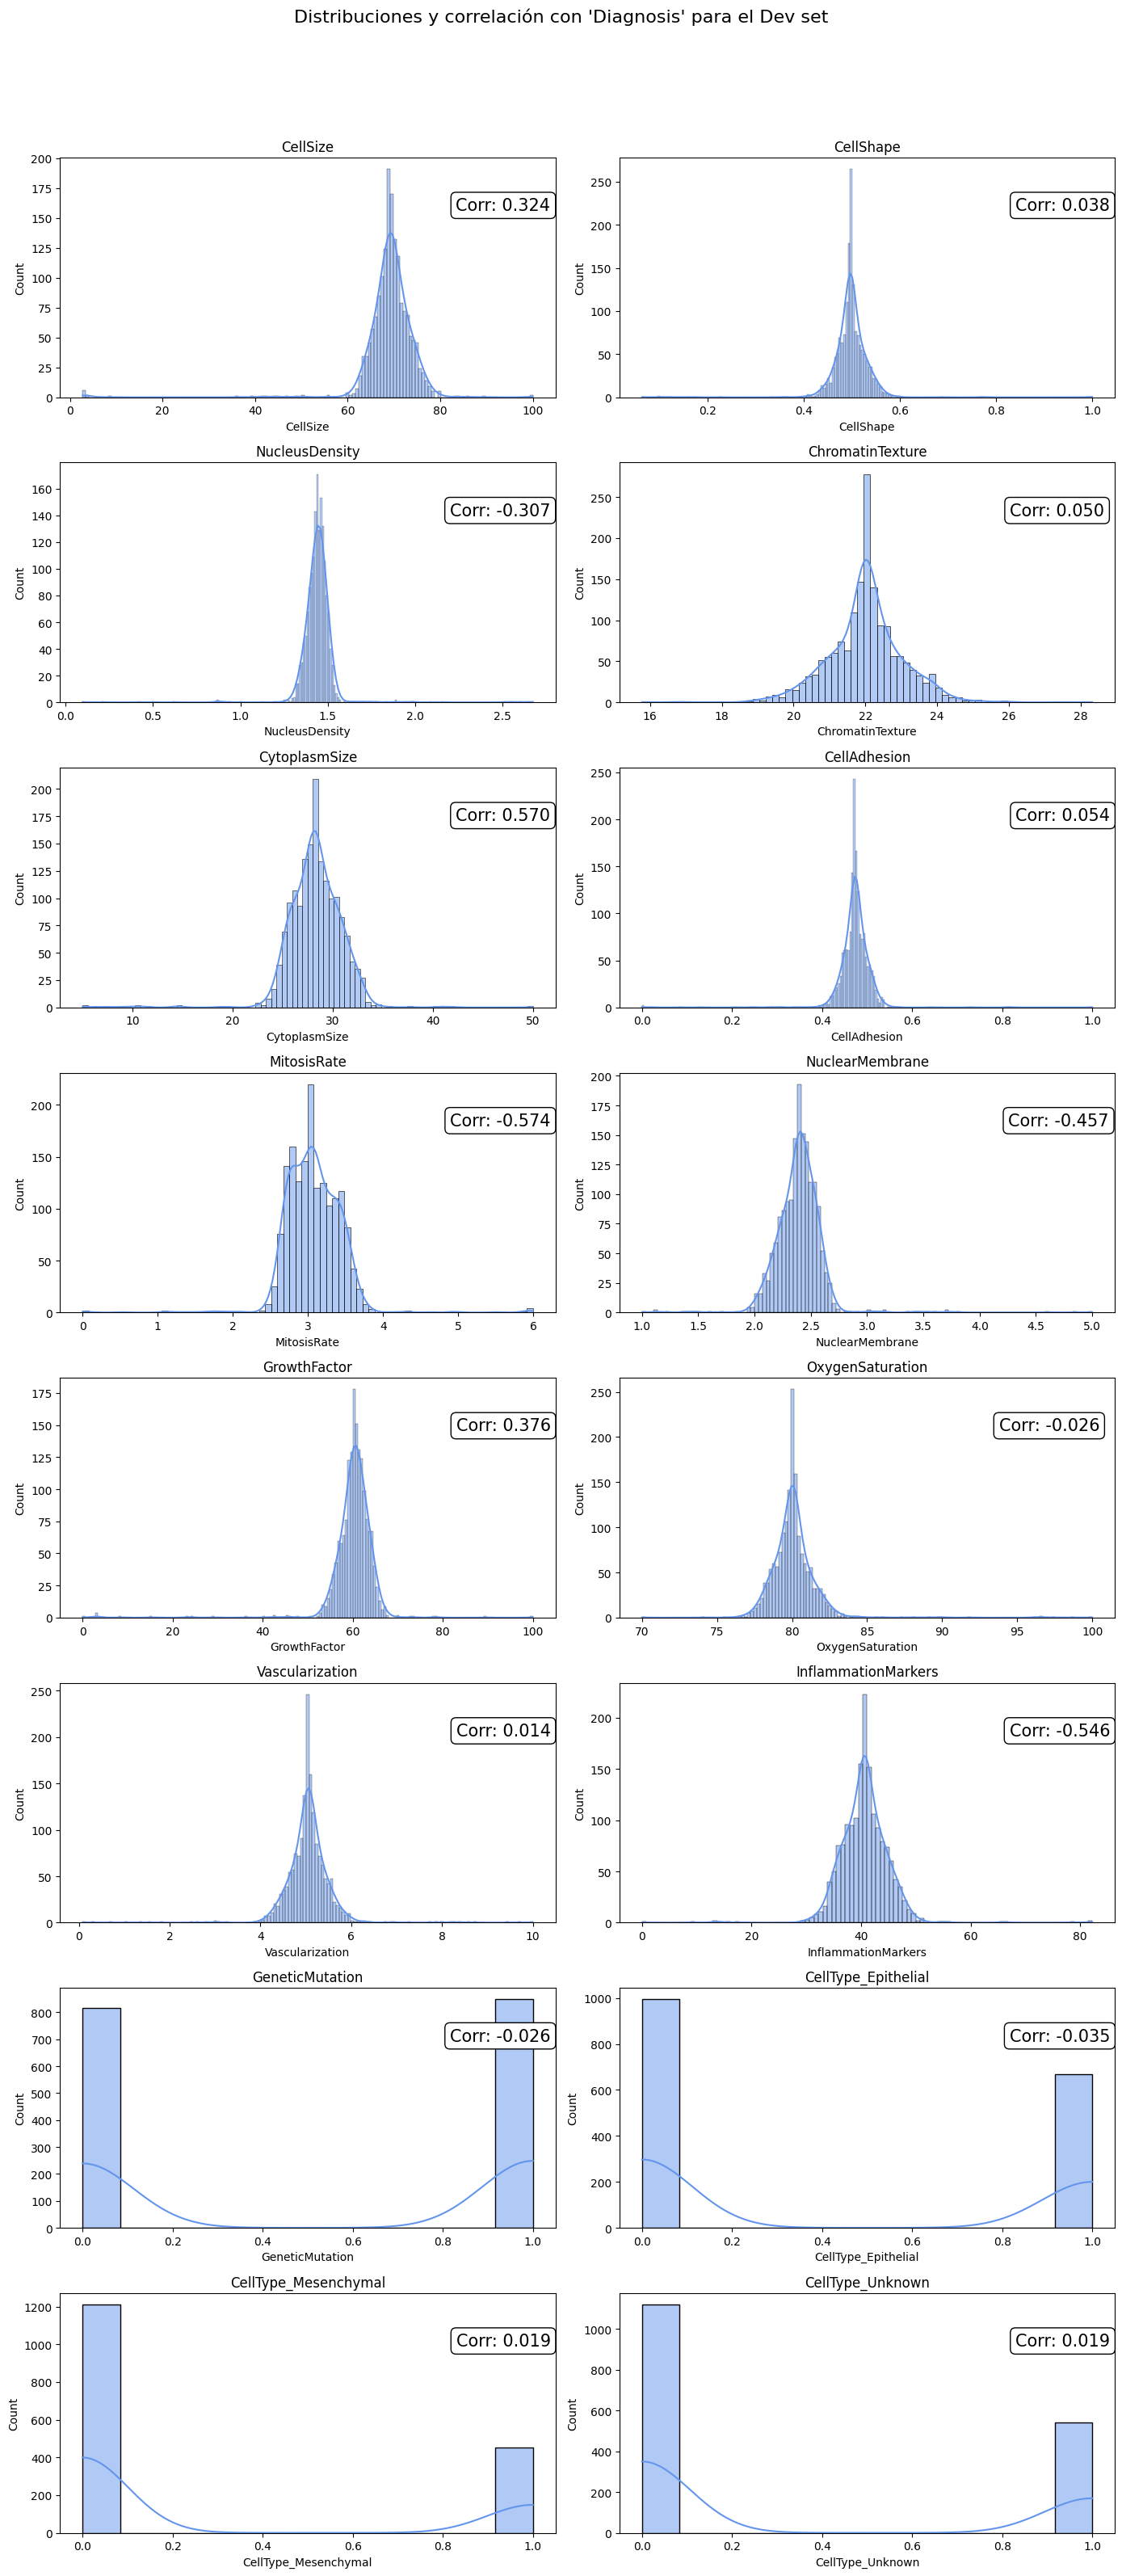

In [18]:
plot_features_with_correlation(diagnosis_dev_filled_OHE_BE, "Dev set", target_col="Diagnosis", batch_size=16)

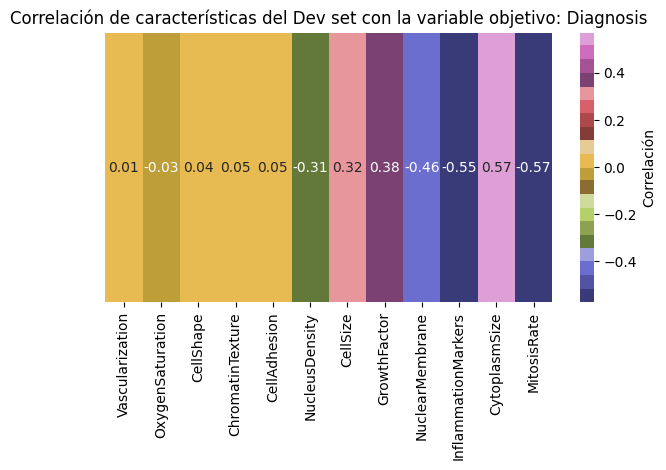

In [19]:
plot_correlations_with_target(diagnosis_dev_filled_OHE_BE, "Dev set", target_col="Diagnosis")

### `1.2)` LogisticRegression implementada en scr.models

In [20]:
from src.models import LogisticRegression
from src.metrics import report_metrics, plot_roc_curve, plot_pr_curve, f1_score
from src.preprocessing import normalize_dataframe
from src.data_splitting import split_train_validation

Tuning del hiperparámetro λ (L2):


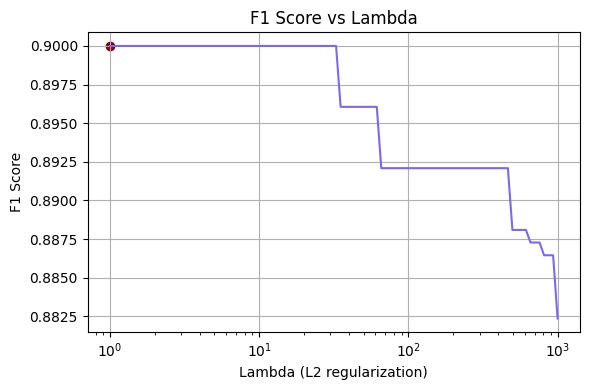


Mejor λ encontrado: 1.0 (F1 = 0.9000)


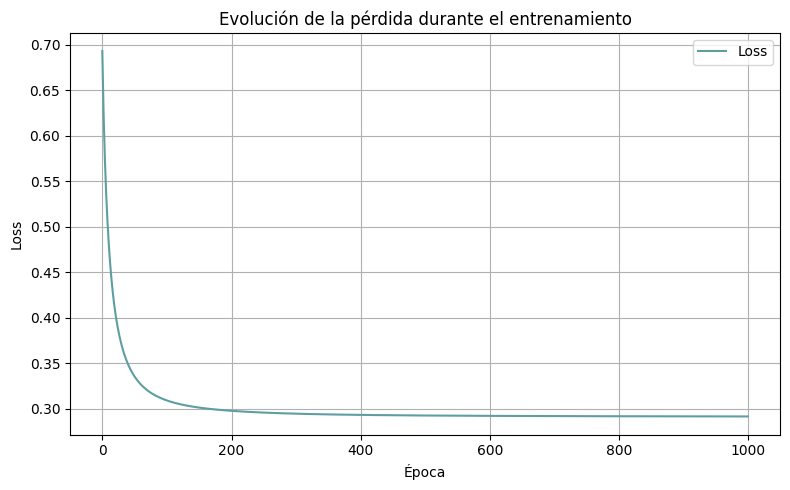


Evaluación en conjunto de validación:


### Métricas de Evaluación para el conjunto de **Validación** del set **Cell Diagnosis**
| Métrica   |   Valor |
|:----------|--------:|
| Accuracy  |  0.9159 |
| Precision |  0.8630 |
| Recall    |  0.9403 |
| F1 Score  |  0.9000 |
| AUC-ROC   |  0.9355 |
| AUC-PR    |  0.8311 |

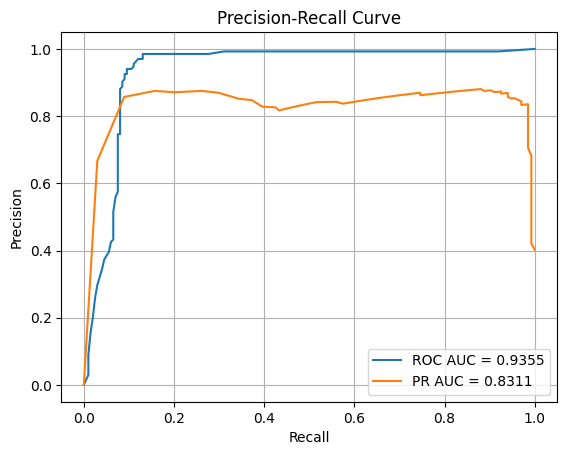

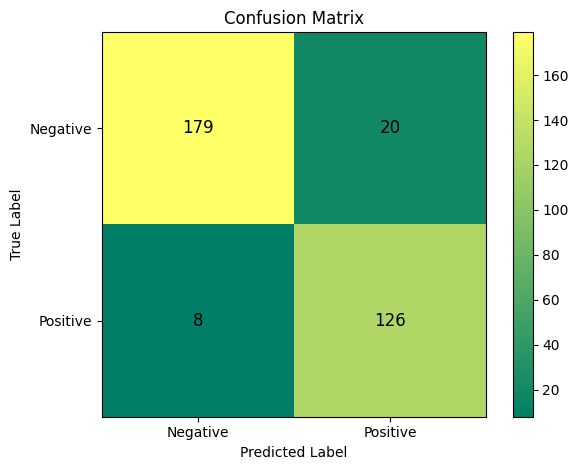

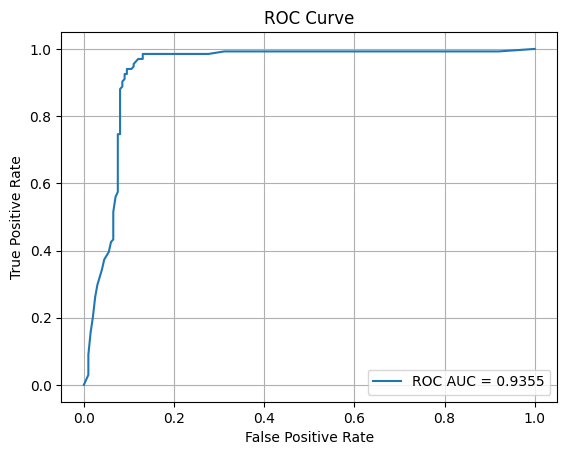

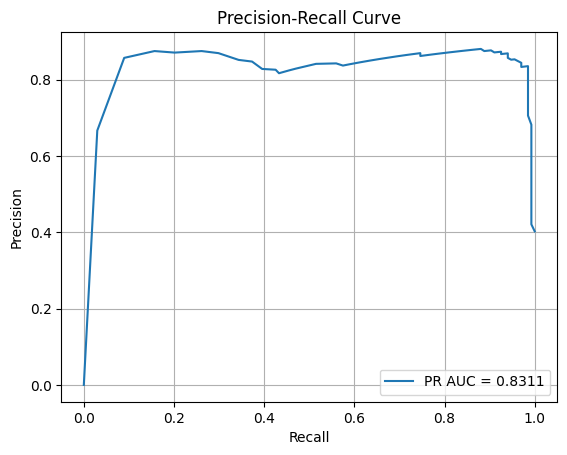

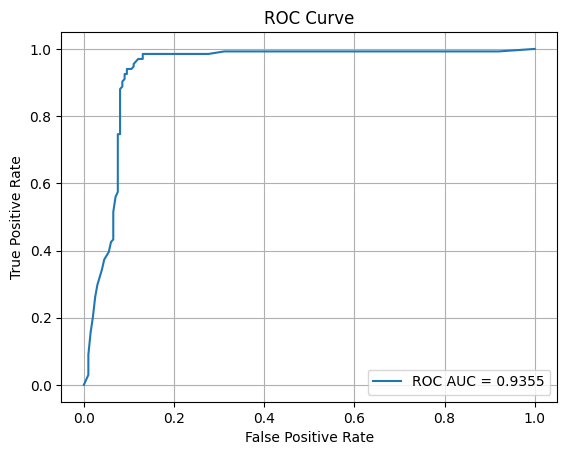

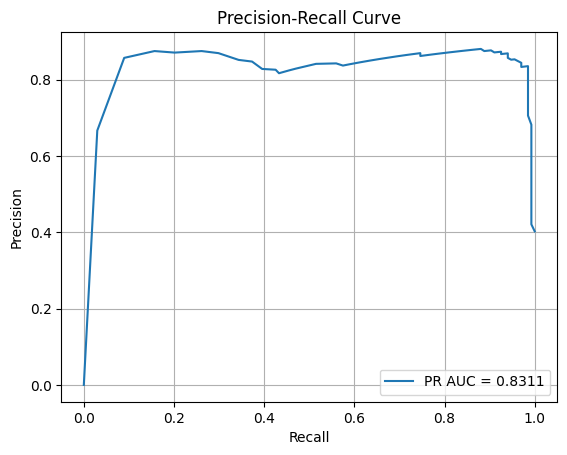

0.8310858177132294

In [21]:
# Constants
TARGET_COLUMN = "Diagnosis"


# 2. Dividir en entrenamiento y validación
diagnosis_train_df, diagnosis_val_df = split_train_validation(diagnosis_dev_filled_OHE_BE, val_ratio=0.2, seed=42)

# 3. Normalizar características (solo las numéricas, usando stats del train)
diagnosis_normalized_train, dev_train_stats = normalize_dataframe(diagnosis_train_df, is_training=True, target_col=TARGET_COLUMN)
diagnosis_normalized_val, _ = normalize_dataframe(diagnosis_val_df, is_training=False, stats=dev_train_stats, target_col=TARGET_COLUMN)

# 4. Separar características y etiquetas
diagnosis_X_train = diagnosis_normalized_train.drop(columns=[TARGET_COLUMN]).values
diagnosis_y_train = diagnosis_normalized_train[TARGET_COLUMN].values

diagnosis_X_val = diagnosis_normalized_val.drop(columns=[TARGET_COLUMN]).values
diagnosis_y_val = diagnosis_normalized_val[TARGET_COLUMN].values

# 5. Búsqueda del mejor lambda (L2 regularization)
best_f1 = -1
best_lambda = None
f1_scores = []
# lambda_values = [0.0, 0.01, 0.1, 1.0, 10.0]
lambda_values = np.logspace(0, 3, 100)

print("Tuning del hiperparámetro λ (L2):")

for lmbd in lambda_values:
    model = LogisticRegression(
        learning_rate=0.1,
        iterations=1000,
        l2=lmbd,
        plot_loss=False
    )
    model.fit(diagnosis_X_train, diagnosis_y_train)
    y_val_pred = model.predict(diagnosis_X_val)

    f1 = f1_score(diagnosis_y_val, y_val_pred)
    f1_scores.append(f1)

    # norma L2 de los pesos para ver efecto de la regularización
    # print(f"λ = {lmbd:.2f} -> F1-score = {f1:.4f}  |  Norma de pesos: {np.linalg.norm(model.weights):.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_lambda = lmbd
    
    
plt.figure(figsize=(6, 4))
plt.plot(lambda_values, f1_scores, c="mediumslateblue")
plt.scatter(best_lambda, best_f1, color='maroon', label='Best Lambda')
plt.xscale('log')
plt.xlabel("Lambda (L2 regularization)")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Lambda")
plt.grid(True)
plt.tight_layout()
plt.show()

# 6. Entrenamiento del modelo final con mejor λ
print(f"\nMejor λ encontrado: {best_lambda} (F1 = {best_f1:.4f})")

final_model = LogisticRegression(
    learning_rate=0.1,
    iterations=1000,
    l2=best_lambda,
    plot_loss=True
)
final_model.fit(diagnosis_X_train, diagnosis_y_train)

# 7. Evaluación final
y_scores = final_model.predict_proba(diagnosis_X_val)
y_pred = (y_scores >= 0.5).astype(int)

print("\nEvaluación en conjunto de validación:")
report_metrics(diagnosis_y_val, y_scores, dataset_name="Cell Diagnosis", set_type="Validación")

# 8. Curvas ROC y PR
plot_roc_curve(diagnosis_y_val, y_scores)
plot_pr_curve(diagnosis_y_val, y_scores)



### `1.3)` Performance del modelo para el conjunto de datos de test cell_diagnosis_balanced_test

In [22]:
from src.preprocessing import calculate_stats_dict

KNN imputing: 100%|██████████| 174/174 [00:00<00:00, 819.46it/s]
c:\Users\anapt\Repositorios\ML-DL\Tissera_AnaPaula_TP2\src\preprocessing.py:101: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_copy[column] = df_copy[column].replace(mapping)


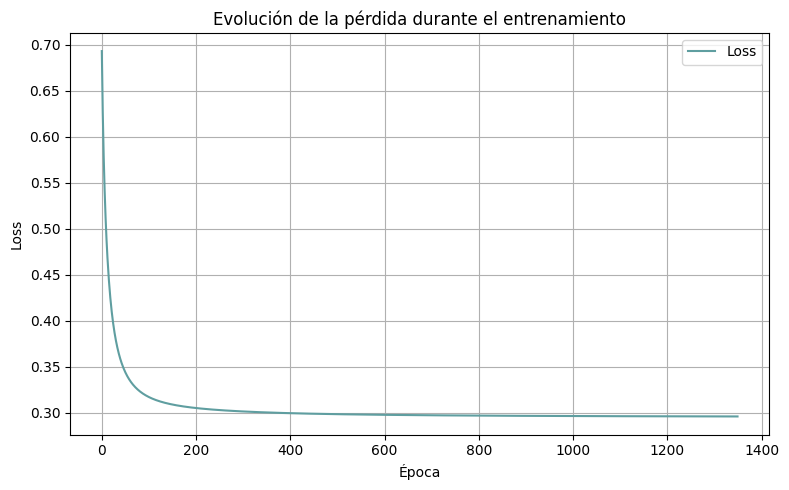


Evaluación en conjunto de test:


### Métricas de Evaluación para el conjunto de **Test** del set **Cell Diagnosis**
| Métrica   |   Valor |
|:----------|--------:|
| Accuracy  |  0.9459 |
| Precision |  0.9398 |
| Recall    |  0.9398 |
| F1 Score  |  0.9398 |
| AUC-ROC   |  0.9613 |
| AUC-PR    |  0.8719 |

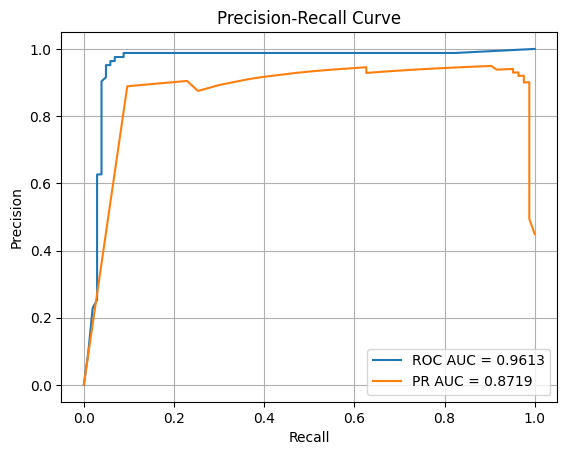

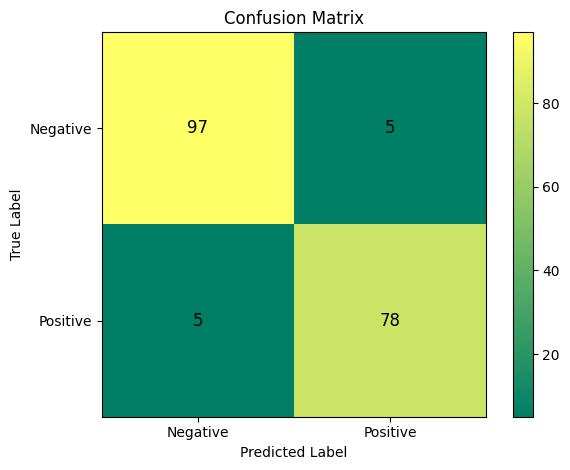

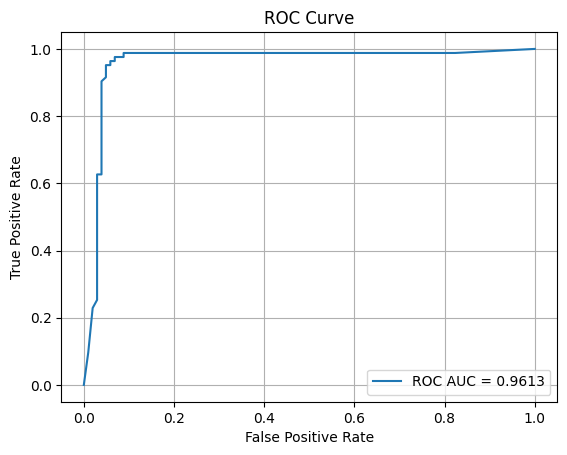

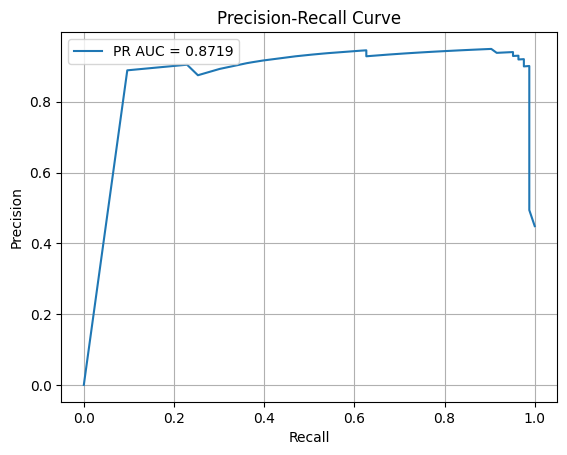

In [23]:
dev_stats_dict = calculate_stats_dict(cell_diagnosis_dev_df)

diagnosis_test_filled = handle_missing_values(
    data=cell_diagnosis_test_df,
    target_col=TARGET_COLUMN,
    train=False,
    reference=diagnosis_dev_filled,
    intervals=valid_ranges,
    stats_dict=dev_stats_dict,
    neighbors=5,
)

diagnosis_test_filled_OHE = one_hot_encode_column(diagnosis_test_filled, 'CellType', corrections=correcciones_celltype)

diagnosis_test_filled_OHE_BE = binary_encode_column(diagnosis_test_filled_OHE, 'GeneticMutation', mapeo_mutacion)

diagnosis_test_filled_OHE_BE = convert_columns_to_int(diagnosis_test_filled_OHE_BE, ['Diagnosis'])


diagnosis_dev_filled_OHE_BE_norm, dev_stats = normalize_dataframe(diagnosis_dev_filled_OHE_BE, is_training=True, target_col=TARGET_COLUMN)
diagnosis_test_filled_OHE_BE_norm, _ = normalize_dataframe(diagnosis_test_filled_OHE_BE, is_training=False, stats=dev_stats, target_col=TARGET_COLUMN)


# entrenar con todo el dataset

X_test = diagnosis_test_filled_OHE_BE_norm.drop(columns=[TARGET_COLUMN])
y_test = diagnosis_test_filled_OHE_BE_norm[TARGET_COLUMN]

X_train = diagnosis_dev_filled_OHE_BE_norm.drop(columns=[TARGET_COLUMN])
y_train = diagnosis_dev_filled_OHE_BE_norm[TARGET_COLUMN]


model = LogisticRegression(
    learning_rate=0.1,
    iterations=1350,
    l2=best_lambda,
    plot_loss=True
)
model.fit(X_train, y_train)

# 7. Evaluación final
y_scores_test = model.predict_proba(X_test)
y_pred = (y_scores_test >= 0.5).astype(int)

print("\nEvaluación en conjunto de test:")
report_metrics(y_test, y_scores_test, dataset_name="Cell Diagnosis", set_type="Test")


#### `1.4)` Rebalanceo de Clases en Conjuntos Desbalanceados

##### `Cell diagnosis `*`Imbalanced`*` Dev Set`

In [24]:
# split the data into train and validation sets
RANDOM_STATE = 42
cell_diagnosis_imbalanced_dev_df
diagnosis_imbalanced_train, diagnosis_imbalanced_val = split_train_validation(cell_diagnosis_imbalanced_dev_df, val_ratio=0.2, seed=RANDOM_STATE)


imbalanced_train_stats_dict = calculate_stats_dict(diagnosis_imbalanced_train)

# Train
diagnosis_imbalanced_train_filled = handle_missing_values(
    data=diagnosis_imbalanced_train,
    target_col=TARGET_COLUMN,
    train=True,
    reference=None,
    intervals=valid_ranges,
    stats_dict=None,
    neighbors=5,
)

diagnosis_imbalanced_train_filled_OHE = one_hot_encode_column(diagnosis_imbalanced_train_filled, 'CellType', corrections=correcciones_celltype)
diagnosis_imbalanced_train_filled_OHE_BE = binary_encode_column(diagnosis_imbalanced_train_filled_OHE, 'GeneticMutation', mapeo_mutacion)
diagnosis_imbalanced_train_filled_OHE_BE = convert_columns_to_int(diagnosis_imbalanced_train_filled_OHE_BE, ['Diagnosis'])

diagnosis_imbalanced_train_filled_OHE_BE_norm, imbalanced_train_stats = normalize_dataframe(diagnosis_imbalanced_train_filled_OHE_BE, is_training=True, target_col=TARGET_COLUMN)
diagnosis_imbalanced_train_filled_OHE_BE_norm.to_csv('data/Problem_1/processed/cell_diagnosis_train_imbalanced_normalized.csv', index=False)

# Validation
diagnosis_imbalanced_val_filled = handle_missing_values(
    data=diagnosis_imbalanced_val,
    target_col=TARGET_COLUMN,
    train=False,
    reference=diagnosis_imbalanced_train_filled,
    intervals=valid_ranges,
    stats_dict=imbalanced_train_stats_dict,
    neighbors=5,
)

diagnosis_imbalanced_val_filled_OHE = one_hot_encode_column(diagnosis_imbalanced_val_filled, 'CellType', corrections=correcciones_celltype)
diagnosis_imbalanced_val_filled_OHE_BE = binary_encode_column(diagnosis_imbalanced_val_filled_OHE, 'GeneticMutation', mapeo_mutacion)
diagnosis_imbalanced_val_filled_OHE_BE = convert_columns_to_int(diagnosis_imbalanced_val_filled_OHE_BE, ['Diagnosis'])

diagnosis_imbalanced_val_filled_OHE_BE_norm, _ = normalize_dataframe(diagnosis_imbalanced_val_filled_OHE_BE, is_training=False, stats=imbalanced_train_stats, target_col=TARGET_COLUMN)
diagnosis_imbalanced_val_filled_OHE_BE_norm.to_csv('data/Problem_1/processed/cell_diagnosis_val_imbalanced_normalized.csv', index=False)



KNN imputing: 100%|██████████| 908/908 [00:01<00:00, 771.46it/s]
c:\Users\anapt\Repositorios\ML-DL\Tissera_AnaPaula_TP2\src\preprocessing.py:101: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_copy[column] = df_copy[column].replace(mapping)
KNN imputing: 100%|██████████| 231/231 [00:00<00:00, 921.33it/s]
c:\Users\anapt\Repositorios\ML-DL\Tissera_AnaPaula_TP2\src\preprocessing.py:101: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_copy[column] = df_copy[column].replace(mapping)


In [25]:
from src.rebalancing import undersampling, oversampling_duplicate_minority_class, basic_SMOTE, cost_sensitive_weights

In [26]:
# 1. No rebalancing
imbalanced_X_train = diagnosis_imbalanced_train_filled_OHE_BE_norm.drop(columns=[TARGET_COLUMN])
imbalanced_y_train = diagnosis_imbalanced_train_filled_OHE_BE_norm[TARGET_COLUMN]
imbalanced_X_val = diagnosis_imbalanced_val_filled_OHE_BE_norm.drop(columns=[TARGET_COLUMN])
imbalanced_y_val = diagnosis_imbalanced_val_filled_OHE_BE_norm[TARGET_COLUMN]

# 2. Undersampling
imbalanced_X_train_undersampled, imbalanced_y_train_undersampled = undersampling(diagnosis_imbalanced_train_filled_OHE_BE_norm, TARGET_COLUMN)

# 2. Oversampling por duplicación de la clase minoritaria
imbalanced_X_train_oversampled, imbalanced_y_train_oversampled = oversampling_duplicate_minority_class(diagnosis_imbalanced_train_filled_OHE_BE_norm, TARGET_COLUMN)

# 4. SMOTE
imbalanced_X_train_smote, imbalanced_y_train_smote = basic_SMOTE(diagnosis_imbalanced_train_filled_OHE_BE_norm, columna_objetivo=TARGET_COLUMN)

# 5. Cost-sensitive weights
sample_weights_train = cost_sensitive_weights(imbalanced_y_train)


In [27]:
from src.metrics import (
    accuracy, precision, recall, f1_score, 
    plot_roc_curve, plot_pr_curve, auc
)

def train_and_evaluate_model(X_train, y_train, X_val, y_val, sample_weights=None):
    """
    Entrena un modelo de regresión logística buscando el mejor lambda
    y evalúa su desempeño sobre el conjunto de validación.
    """
    lambda_values = np.logspace(0, 3, 100)
    best_f1 = -1
    best_lambda = None

    for lmbd in lambda_values:
        model = LogisticRegression(
            learning_rate=0.1,
            iterations=1000,
            l2=lmbd,
            plot_loss=False
        )
        model.fit(X_train, y_train, sample_weights=sample_weights)
        y_pred = model.predict(X_val)
        f1 = f1_score(y_val, y_pred)

        if f1 > best_f1:
            best_f1 = f1
            best_lambda = lmbd

    # Entrenamos con el mejor lambda
    final_model = LogisticRegression(
        learning_rate=0.1,
        iterations=1000,
        l2=best_lambda,
        plot_loss=False
    )
    final_model.fit(X_train, y_train, sample_weights=sample_weights)
    y_scores = final_model.predict_proba(X_val)
    y_pred = (y_scores >= 0.5).astype(int)

    # Calculamos todas las métricas
    acc = accuracy(y_val, y_pred)
    prec = precision(y_val, y_pred)
    rec = recall(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    auc_roc = plot_roc_curve(y_val, y_scores, show=False)
    auc_pr = plot_pr_curve(y_val, y_scores, show=False)

    return {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F-Score": f1,
        "AUC-ROC": auc_roc,
        "AUC-PR": auc_pr,
        "y_scores": y_scores,  # para graficar
        "y_true": y_val
    }


In [32]:
def evaluar_modelos_rebalanceo(
    X_val, y_val,
    train_sets: dict
):
    """
    train_sets: diccionario con clave=str (nombre del método)
                y valor=(X_train, y_train, sample_weights o None)
    """
    resultados = []
    curvas_roc = []
    curvas_pr = []

    for nombre, (X_train, y_train, sample_weights) in train_sets.items():
        print(f"Evaluando modelo: {nombre}")
        resultado = train_and_evaluate_model(X_train, y_train, X_val, y_val, sample_weights)
        curvas_roc.append((nombre, resultado["y_true"], resultado["y_scores"]))
        curvas_pr.append((nombre, resultado["y_true"], resultado["y_scores"]))

        resultados.append({
            "Modelo": nombre,
            "Accuracy": resultado["Accuracy"],
            "Precision": resultado["Precision"],
            "Recall": resultado["Recall"],
            "F-Score": resultado["F-Score"],
            "AUC-ROC": resultado["AUC-ROC"],
            "AUC-PR": resultado["AUC-PR"]
        })

    df_resultados = pd.DataFrame(resultados)
    display(Markdown(df_resultados.to_markdown(index=False)))

    # Graficar curvas ROC
    plt.figure(figsize=(6, 5))
    for nombre, y_true, y_scores in curvas_roc:
        plot_roc_curve(y_true, y_scores, label=nombre, show=False)
    plt.title("Curva ROC - Comparación de modelos")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Graficar curvas PR
    plt.figure(figsize=(6, 5))
    for nombre, y_true, y_scores in curvas_pr:
        plot_pr_curve(y_true, y_scores, label=nombre, show=False)
    plt.title("Curva Precision-Recall - Comparación de modelos")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return df_resultados


Evaluando modelo: Sin rebalanceo
Evaluando modelo: Undersampling
Evaluando modelo: Oversampling duplicate
Evaluando modelo: Oversampling SMOTE
Evaluando modelo: Cost re-weighting


| Modelo                 |   Accuracy |   Precision |   Recall |   F-Score |   AUC-ROC |   AUC-PR |
|:-----------------------|-----------:|------------:|---------:|----------:|----------:|---------:|
| Sin rebalanceo         |   0.897541 |    0.75     | 0.885246 |  0.81203  |  0.944146 | 0.717084 |
| Undersampling          |   0.913934 |    0.743902 | 1        |  0.853147 |  0.945669 | 0.717195 |
| Oversampling duplicate |   0.913934 |    0.75     | 0.983607 |  0.851064 |  0.938457 | 0.698991 |
| Oversampling SMOTE     |   0.905738 |    0.731707 | 0.983607 |  0.839161 |  0.943026 | 0.699787 |
| Cost re-weighting      |   0.909836 |    0.740741 | 0.983607 |  0.84507  |  0.943788 | 0.714312 |

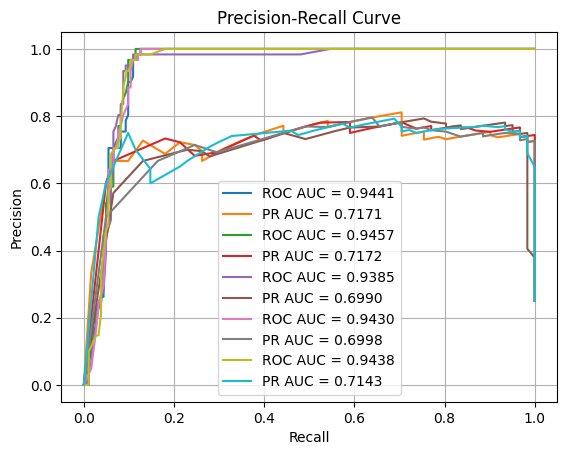

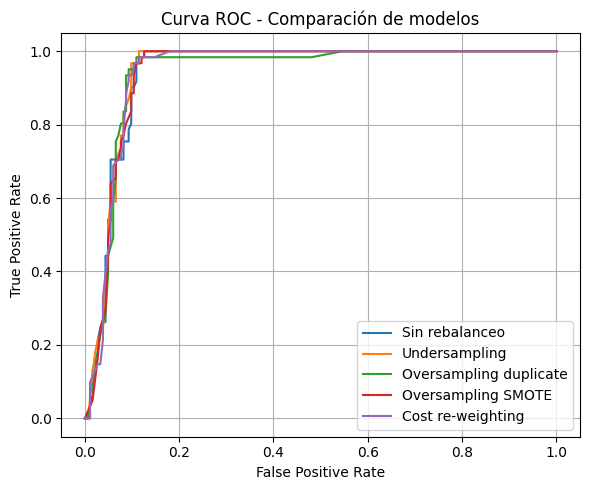

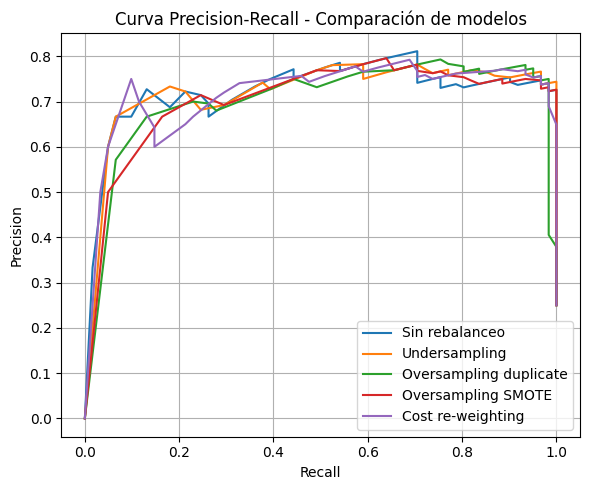

In [33]:
train_sets = {
    "Sin rebalanceo": (
        imbalanced_X_train.values, 
        imbalanced_y_train.values, 
        None
    ),
    "Undersampling": (
        imbalanced_X_train_undersampled.values, 
        imbalanced_y_train_undersampled.values, 
        None
    ),
    "Oversampling duplicate": (
        imbalanced_X_train_oversampled.values, 
        imbalanced_y_train_oversampled.values, 
        None
    ),
    "Oversampling SMOTE": (
        imbalanced_X_train_smote.values, 
        imbalanced_y_train_smote.values, 
        None
    ),
    "Cost re-weighting": (
        imbalanced_X_train.values, 
        imbalanced_y_train.values, 
        sample_weights_train
    ),
}

tabla_resultados = evaluar_modelos_rebalanceo(
    imbalanced_X_val.values,
    imbalanced_y_val.values,
    train_sets
)